## Comparing peaks list obtained with centroid and profile mode.
Comparing peaks list obtained from profile and centroid mode of the same data.

Loading data. If test data is not available it will be downloaded from OSF.

In [1]:
%load_ext autoreload
%autoreload 2

import pastaq as pq
import os
import numpy as np
import pandas as pd
import seaborn as sns
import math as m
import matplotlib.pyplot as plt
from helpers import (
    plot_msSpectra,
    plot_meshPeaks,
    plot_meshRawPeaks,
    print_64bit_as_bytes,
    plot_meshPeaks_interactive,
    downloadTestFilesFromOSF,
    XICVisualisation,
    showXICRAWAligned,
    plot_feature_zoom,
    match_peaks_within_sigma,
    plot_matched_peaks_scatter,
    plot_MA_matched_peaks_scatter
)

# Download example files from OSF if they don't exist
downloadTestFilesFromOSF()

# Now you can use 'examples/data/' as your sample_data_dir
sample_data_dir = os.path.join(os.getcwd(), "data") + "/"

exampleFile1 = sample_data_dir + '3_1_extract_3400_4100_590_615.mzML'
exampleFile2 = sample_data_dir + '3_2_extract_3400_4100_590_615.mzML'
exampleFile1c = sample_data_dir + '3_1_extract_3400_4100_590_615_c.mzML'
exampleFile2c = sample_data_dir + '3_2_extract_3400_4100_590_615_c.mzML'

# set average FWHM of chromatographic peaks to 25 seconds
avg_fwhm_rt = 25 # default 15

# load two example files for MS1 and MS2 layers
lcmsData1 = pq.read_mzml(exampleFile1, fwhm_rt = avg_fwhm_rt, ms_level = 1)
lcmsDataMS2_1 = pq.read_mzml(exampleFile1, fwhm_rt = avg_fwhm_rt, ms_level = 2)
lcmsData2 = pq.read_mzml(exampleFile2, fwhm_rt = avg_fwhm_rt, ms_level = 1)
lcmsDataMS2_2 = pq.read_mzml(exampleFile2, fwhm_rt = avg_fwhm_rt, ms_level = 2)
lcmsData1c = pq.read_mzml(exampleFile1c, fwhm_rt = avg_fwhm_rt, ms_level = 1)
lcmsDataMS2_1c = pq.read_mzml(exampleFile1c, fwhm_rt = avg_fwhm_rt, ms_level = 2)
lcmsData2c = pq.read_mzml(exampleFile2c, fwhm_rt = avg_fwhm_rt, ms_level = 1)
lcmsDataMS2_2c = pq.read_mzml(exampleFile2c, fwhm_rt = avg_fwhm_rt, ms_level = 2)

# Get the default parameters and change the resolution of MS2 to 17500.
params = pq.default_parameters(avg_fwhm_rt = avg_fwhm_rt)
params['resolution_msn'] = 17500

# Print the parameters used to load the two files.
print("Paramaters of the raw data:\n", params)

print(lcmsData1)

Checking mzML files in 'data/'...
All mzML files are present and have correct size. No download needed.
Paramaters of the raw data:
 {'instrument_type': 'orbitrap', 'resolution_ms1': 70000, 'resolution_msn': 17500, 'reference_mz': 200, 'avg_fwhm_rt': 25, 'num_samples_mz': 5, 'num_samples_rt': 5, 'smoothing_coefficient_mz': 0.4, 'smoothing_coefficient_rt': 0.4, 'warp2d_slack': 30, 'warp2d_window_size': 100, 'warp2d_num_points': 2000, 'warp2d_rt_expand_factor': 0.2, 'warp2d_peaks_per_window': 100, 'metamatch_fraction': 0.7, 'metamatch_n_sig_mz': 1.5, 'metamatch_n_sig_rt': 1.5, 'feature_detection_charge_states': [5, 4, 3, 2, 1], 'max_peaks': 1000000, 'polarity': 'both', 'min_mz': 0, 'max_mz': 100000, 'min_rt': 0, 'max_rt': 100000, 'link_n_sig_mz': 3, 'link_n_sig_rt': 3, 'ident_max_rank_only': True, 'ident_require_threshold': True, 'ident_ignore_decoy': True, 'similarity_num_peaks': 2000, 'qc_plot_palette': 'husl', 'qc_plot_extension': 'png', 'qc_plot_fill_alpha': 'dynamic', 'qc_plot_line_

In [2]:
smoothParamProfile = [[5, 5, 0.4, 0.6], [10, 10, 0.4, 0.6]]
smoothParamCentroid = [[5, 5, 0.8, 0.6], [10, 10, 0.8, 0.6]]
i= 0
# processing the whole file for profile and centroid data
lcmsData1.get_failed_peaks = False
grid1 = pq.resample(lcmsData1, smoothParamProfile[i][0], smoothParamProfile[i][1], smoothParamProfile[i][2], smoothParamProfile[i][3])
peaks1 = pq.find_peaks(lcmsData1c, grid1, params['max_peaks'])
locMax1 = pq.find_local_maxima(grid1)

lcmsData1c.get_failed_peaks = False
grid1c = pq.resample(lcmsData1c, smoothParamCentroid[i][0], smoothParamCentroid[i][1], smoothParamCentroid[i][2], smoothParamCentroid[i][3])
peaks1c = pq.find_peaks(lcmsData1c, grid1c, params['max_peaks'])
locMax1c = pq.find_local_maxima(grid1c)

# print the number of peaks
print("Number of peaks in profile data: ", len(peaks1))
print("Number of peaks in centroid data: ", len(peaks1c))

print("First peak in profile data: ", peaks1[0].fitted_mz, peaks1[0].fitted_rt)
print("First peak in centroid data: ", peaks1c[0].fitted_mz, peaks1c[0].fitted_rt)

# print(lcmsData1.get_theoretical_sigma_mz(peaks1[0].fitted_mz))

Number of peaks in profile data:  2478
Number of peaks in centroid data:  2558
First peak in profile data:  598.9694206790726 3652.899279248809
First peak in centroid data:  598.9697920695161 3652.9073846585775


## Print the main characteristics of LC-MS(/MS) data and the first 20 intensities of the MS1 spectra with id of 20.
Print also statistics on mz, rt and log2 intensity differences.

In [3]:
# Match peaks between profile and centroid data
matched_peaks = match_peaks_within_sigma(
    peaks1, 
    peaks1c, 
    lcmsData1, 
    lcmsData1c, 
    n_sigma_mz=1, 
    n_sigma_rt=1
)

# Print matching statistics
print(f"Total peaks in profile data: {len(peaks1)}")
print(f"Total peaks in centroid data: {len(peaks1c)}")
print(f"Number of matched peaks: {len(matched_peaks)}")
print(f"Matching rate: {len(matched_peaks)/min(len(peaks1), len(peaks1c))*100:.1f}%\n")

# Display first 10 matches
print("First 10 matched peaks:")
print(f"{'Profile':<8} {'Centroid':<9} {'m/z Diff':<10} {'RT Diff':<9} {'m/z σ':<8} {'RT σ':<8} {'Distance':<8} {'profile_peak_intensity':<20} {'centroid_peak_intensity':<20}")
print("-" * 80)
for match in matched_peaks[:10]:
    print(f"{match['profile_idx']:<8} {match['centroid_idx']:<9} "
          f"{match['mz_diff']:<10.6f} {match['rt_diff']:<9.2f} "
          f"{match['mz_diff_sigma']:<8.3f} {match['rt_diff_sigma']:<8.3f} "
          f"{match['distance']:<8.3f} {match['profile_peak_intensity']:<20.3f}"
          f"{match['centroid_peak_intensity']:<20.3f}")

# Create a summary DataFrame for further analysis
import pandas as pd
df_matched = pd.DataFrame(matched_peaks)
print(f"\nSummary statistics:")
print(df_matched[['mz_diff', 'rt_diff', 'mz_diff_sigma', 'rt_diff_sigma', 'distance', 'profile_centroid_intensity_log2ratio']].describe())

Total peaks in profile data: 2478
Total peaks in centroid data: 2558
Number of matched peaks: 2338
Matching rate: 94.4%

First 10 matched peaks:
Profile  Centroid  m/z Diff   RT Diff   m/z σ    RT σ     Distance profile_peak_intensity centroid_peak_intensity
--------------------------------------------------------------------------------
0        0         0.000371   0.01      0.059    0.001    0.059    67419291.270        66515899.981        
1        1         0.000371   0.03      0.059    0.003    0.059    48166850.665        48122872.265        
2        2         0.000383   0.00      0.059    0.000    0.059    39686955.497        39963391.682        
3        3         0.002544   0.04      0.412    0.004    0.412    34397457.306        34136211.785        
4        4         0.000372   0.01      0.059    0.001    0.059    33742184.332        33947938.936        
5        5         0.000383   0.00      0.059    0.000    0.059    30846653.207        31190915.888        
6        6  

## Scatter plot of log2 intensity difference between centroid and profile peak lists.
Log2 intensity differences are shown in function of m/z (x axis) and mean intensity using color map of matched profile and centroid peaks.


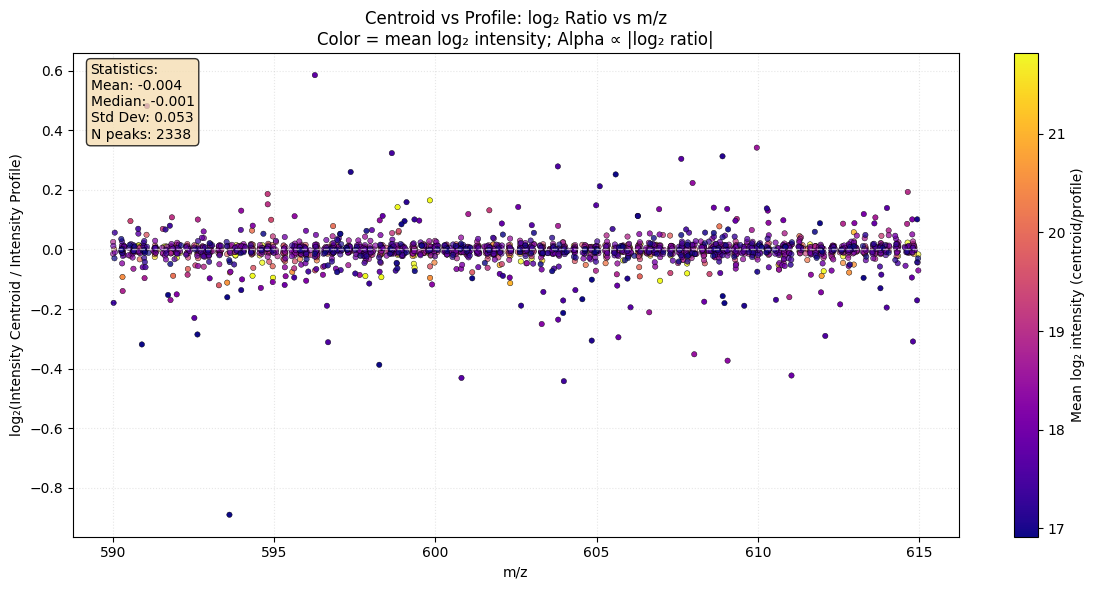

In [4]:
imagematchedcentroid = plot_matched_peaks_scatter(
    matched_peaks, min_alpha=0.6)

## Fold change differences between profile and centroid peak detection using the same dataset sorted according to profile peak intensity

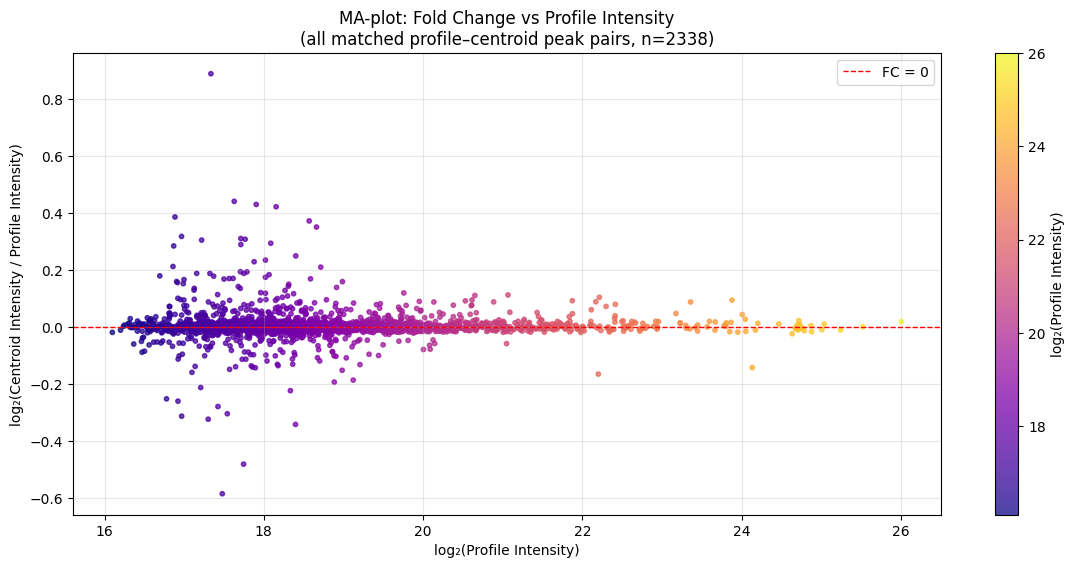

In [12]:
# Same plot as above but sorted by profile intensity from low to high
plot_MA_matched_peaks_scatter(
    matched_peaks,
    min_alpha=0.75,
    title='MA-plot: Fold Change vs Profile Intensity\n(all matched profile–centroid peak pairs, sorted by profile intensity, n={})'.format(len(matched_peaks)),
    figsize=(14, 6)
)


## Statistics on 10 matched profile and centroid peaks showing the largest log2 intensity differences.
Detailed statistics of the 10 matched profile and centroid peaks that shows the highest log2 intensity differences.


Top 10 matched peaks with highest absolute log2 intensity ratio:
Profile  Centroid  Profile Int     Centroid Int    log2 Ratio   Abs log2     m/z        RT      
-------------------------------------------------------------------------------------------------------------------
2149     2536      165439.99       89280.09        0.890        0.890        593.6126   3543.2  
2071     1605      182682.38       274011.16       -0.585       0.585        596.2629   3972.2  
1868     1452      219859.07       306864.89       -0.481       0.481        591.0554   4007.4  
1958     2292      202641.76       149186.05       0.442        0.442        603.9850   3474.6  
1736     2124      245377.81       182025.58       0.431        0.431        600.8098   3416.5  
1492     1935      291841.68       217708.61       0.423        0.423        611.0457   3957.9  
2348     2526      121009.71       92545.91        0.387        0.387        598.2593   3850.4  
1133     1486      389029.03       300389.

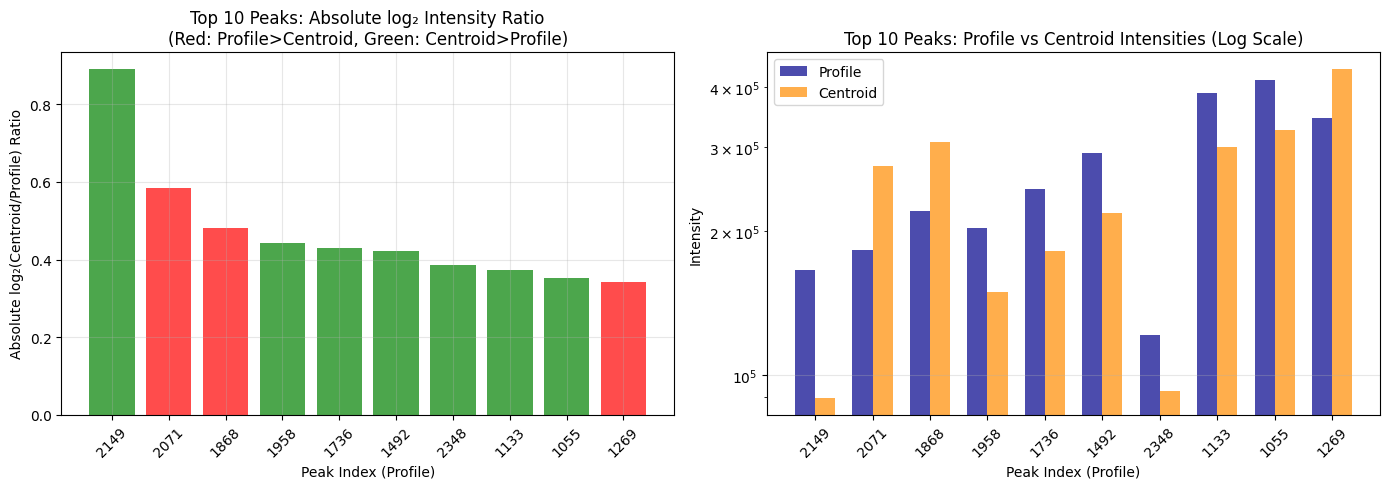

In [6]:
# Get the 10 matched peaks with the highest absolute log2 intensity ratio
# Use the log2 ratio already stored in matched_peaks
log2_ratio_analysis = []
for match in matched_peaks:
    log2_ratio = match.get('profile_centroid_intensity_log2ratio', np.nan)
    if not np.isnan(log2_ratio):
        log2_ratio_analysis.append({
            **match,  # Include all original match data
            'abs_log2_ratio': abs(log2_ratio)
        })

# Sort by absolute log2 ratio (descending)
log2_ratio_sorted = sorted(log2_ratio_analysis, key=lambda x: x['abs_log2_ratio'], reverse=True)

# Get top 10
top_10_log2_ratio = log2_ratio_sorted[:10]

# Display results
print("\nTop 10 matched peaks with highest absolute log2 intensity ratio:")
print(f"{'Profile':<8} {'Centroid':<9} {'Profile Int':<15} {'Centroid Int':<15} {'log2 Ratio':<12} {'Abs log2':<12} {'m/z':<10} {'RT':<8}")
print("-" * 115)
for match in top_10_log2_ratio:
    print(f"{match['profile_idx']:<8} {match['centroid_idx']:<9} "
          f"{match['profile_peak_intensity']:<15.2f} {match['centroid_peak_intensity']:<15.2f} "
          f"{match['profile_centroid_intensity_log2ratio']:<12.3f} {match['abs_log2_ratio']:<12.3f} "
          f"{match['mz_profile']:<10.4f} {match['rt_profile']:<8.1f}")

# Create DataFrame for further analysis
df_top_log2_ratio = pd.DataFrame(top_10_log2_ratio)
print("\nStatistics for top 10 absolute log2 intensity ratios:")
print(df_top_log2_ratio[['abs_log2_ratio', 'profile_centroid_intensity_log2ratio', 'profile_peak_intensity', 'centroid_peak_intensity']].describe())

# Visualize these peaks
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Absolute log2 intensity ratios
indices = [f"{m['profile_idx']}" for m in top_10_log2_ratio]
abs_log2_ratios = [m['abs_log2_ratio'] for m in top_10_log2_ratio]
colors = ['red' if m['profile_centroid_intensity_log2ratio'] < 0 else 'green' for m in top_10_log2_ratio]
ax1.bar(indices, abs_log2_ratios, color=colors, alpha=0.7)
ax1.set_xlabel('Peak Index (Profile)')
ax1.set_ylabel('Absolute log₂(Centroid/Profile) Ratio')
ax1.set_title('Top 10 Peaks: Absolute log₂ Intensity Ratio\n(Red: Profile>Centroid, Green: Centroid>Profile)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# Plot 2: Profile vs Centroid intensities (log scale)
profile_ints = [m['profile_peak_intensity'] for m in top_10_log2_ratio]
centroid_ints = [m['centroid_peak_intensity'] for m in top_10_log2_ratio]
x = np.arange(len(indices))
width = 0.35
ax2.bar(x - width/2, profile_ints, width, label='Profile', color='darkblue', alpha=0.7)
ax2.bar(x + width/2, centroid_ints, width, label='Centroid', color='darkorange', alpha=0.7)
ax2.set_xlabel('Peak Index (Profile)')
ax2.set_ylabel('Intensity')
ax2.set_yscale('log')
ax2.set_title('Top 10 Peaks: Profile vs Centroid Intensities (Log Scale)')
ax2.set_xticks(x)
ax2.set_xticklabels(indices, rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Profile peak index: 2149
Centroid peak index: 2536
Profile peak details: Peak <id: 2149, local_max_mz: 593.612579, local_max_rt: 3544.887734, local_max_height: 41463.441867, fitted_height: 165439.986236, fitted_mz: 593.612579, fitted_rt: 3543.222327, fitted_sigma_mz: 0.006204, fitted_sigma_rt: 4.041371, fitted_volume: 26063.515737>
Centroid peak details: Peak <id: 2536, local_max_mz: 593.610024, local_max_rt: 3544.887734, local_max_height: 11458.922998, fitted_height: 89280.092110, fitted_mz: 593.610024, fitted_rt: 3545.065241, fitted_sigma_mz: 0.006204, fitted_sigma_rt: 8.599672, fitted_volume: 29929.362485>
Main characteristics of LCMS data:
 <bound method PyCapsule.dump of RawData:
> instrument_type: ORBITRAP
> resolution_ms1: 70000.000000
> resolution_msn: 17500.000000
> reference_mz: 200.000000
> centroid data: 0
> min_mz: 593.235383
> max_mz: 594.089899
> min_rt: 3443.479200
> max_rt: 3643.151760
> number of scans: 245> 

Zoomed m/z range: 593.1126 - 594.1126 Da
Zoomed RT range: 

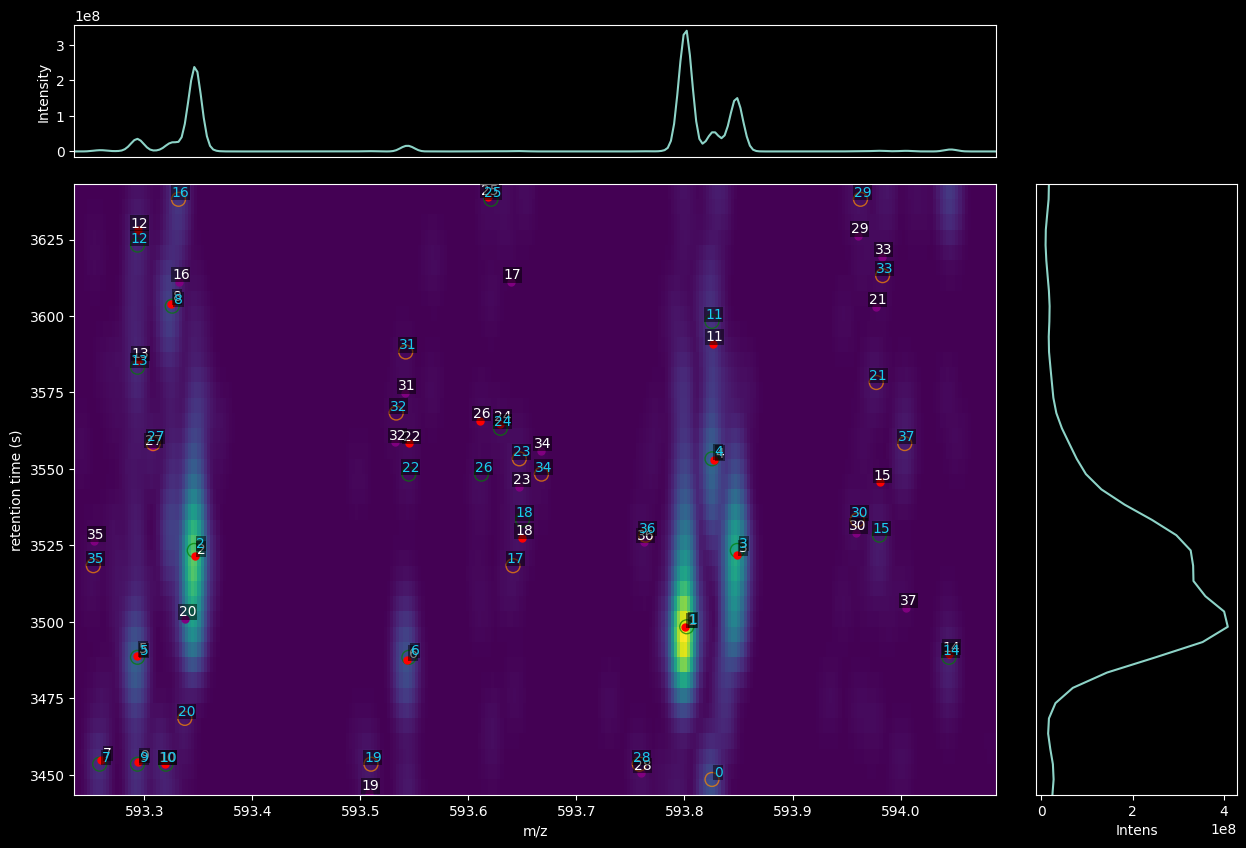

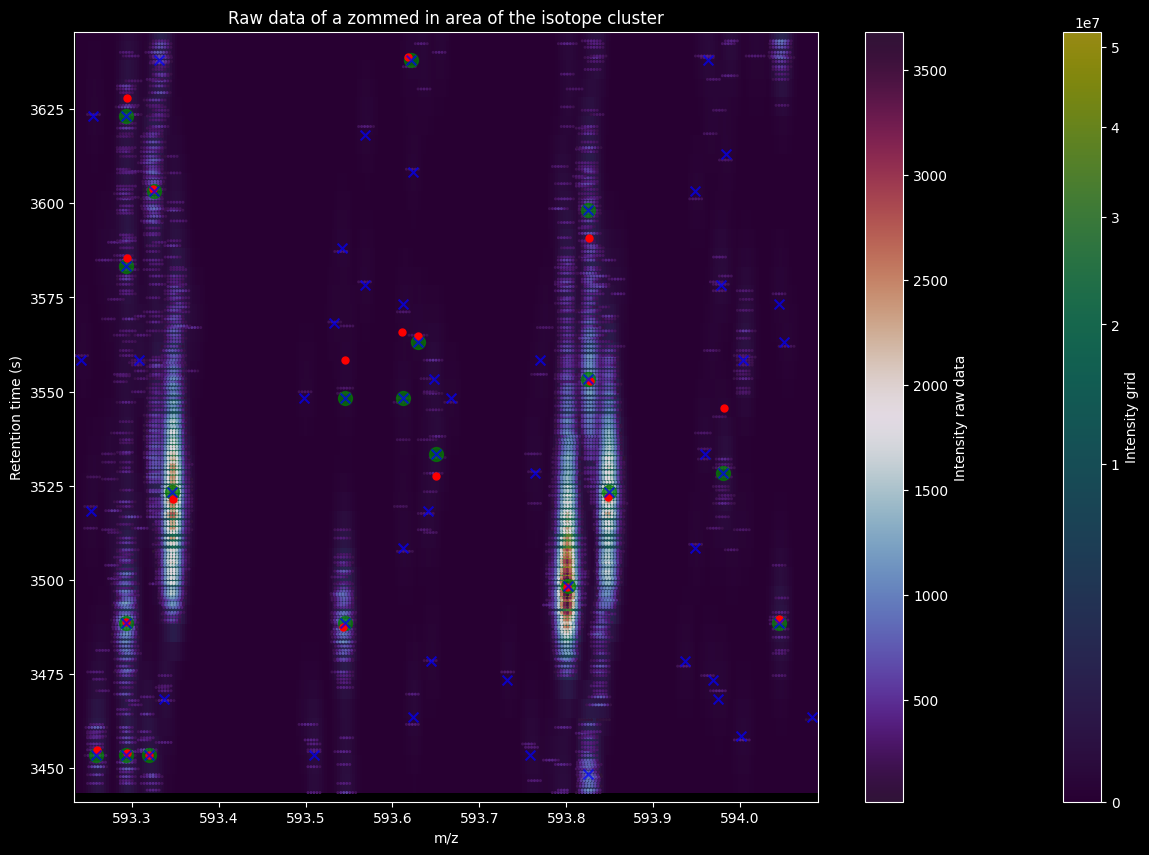

Peak <id: 13, local_max_mz: 593.293770, local_max_rt: 3583.249992, local_max_height: 580820.279765, fitted_height: 300999.102562, fitted_mz: 593.294396, fitted_rt: 3585.434048, fitted_sigma_mz: 0.005417, fitted_sigma_rt: 13.715166, fitted_volume: 140514.912384>


In [7]:
rtp = 50 # retention in seconds added to isotope cluster monoisotopic peak m/z value (define the positive extension range of the plot in retention time)
rtm = 50 # retention in seconds substracted to isotope cluster monoisotopic peak m/z value (define the negative extension range of the plot in retention time)
mzm = 0.5 # m/z in Da added to isotope cluster monoisotopic peak m/z value (define the positive extension range of the plot in m/z)
mzp = 0.5 # m/z in Da substracted to isotope cluster monoisotopic peak m/z value (define the negative extension range of the plot in m/z)

profilePeakIdx = log2_ratio_sorted[0]['profile_idx']
print('Profile peak index: ' + str(profilePeakIdx))
centroidPeakIdx = log2_ratio_sorted[0]['centroid_idx']
print('Centroid peak index: ' + str(centroidPeakIdx))
print('Profile peak details: ' + str(peaks1[profilePeakIdx]))
print('Centroid peak details: ' + str(peaks1c[centroidPeakIdx]))

peak1Idx = profilePeakIdx
rtFactor = 2
# Rereading the file with the mz and rt range zoomed to a peak area
lcmsData1rDiff1 = pq.read_mzml(input_file = exampleFile1, min_mz = peaks1[peak1Idx].fitted_mz-mzm, max_mz = peaks1[peak1Idx].fitted_mz+mzp, min_rt = peaks1[peak1Idx].fitted_rt-rtm*rtFactor, max_rt = peaks1[peak1Idx].fitted_rt+rtp*rtFactor, instrument_type = 'ORBITRAP', resolution_ms1 = 70000, resolution_msn = 17500, reference_mz = 200, fwhm_rt = avg_fwhm_rt, polarity = '+', ms_level = 1)
print('Main characteristics of LCMS data:\n', lcmsData1rDiff1.dump, '\n')
print('Zoomed m/z range: {:.4f} - {:.4f} Da'.format(peaks1[peak1Idx].fitted_mz-mzm, peaks1[peak1Idx].fitted_mz+mzp))
print('Zoomed RT range: {:.1f} - {:.1f} seconds'.format(peaks1[peak1Idx].fitted_rt-rtm*rtFactor, peaks1[peak1Idx].fitted_rt+rtp*rtFactor))
print('Profile peak details: ', peaks1[peak1Idx])

# get peaks Gaussian fit diagnostic data and failed peaks
lcmsData1rDiff1.get_failed_peaks = True

# create smoothed 2D grid, perform centroid data specific peak picking and visualize the results
i = 0
grid1rDiff1 = pq.resample(lcmsData1rDiff1, smoothParamProfile[i][0], smoothParamProfile[i][1], smoothParamProfile[i][2], smoothParamProfile[i][3]) #num_samples_mz, num_samples_rt, smoothing_coefficient_mz, smoothing_coefficient_rt
peaks1rDiff1 = pq.find_peaks(lcmsData1rDiff1, grid1rDiff1, params['max_peaks'])
localMax1rDiff1 = pq.find_local_maxima(grid1rDiff1)
plotMeshProfile = plot_meshPeaks(grid1rDiff1, peaks1rDiff1, localMax1rDiff1, withFailedPeaks=True, showIndeces=True)
plotMeshProfileRaw = plot_meshRawPeaks(grid1rDiff1, lcmsData1rDiff1, peaks1rDiff1, localMax1rDiff1)
print(peaks1rDiff1[13])

# Add 'x' marker at the original peak location from peaks1
target_mz = peaks1[peak1Idx].fitted_mz
target_rt = peaks1[peak1Idx].fitted_rt

# Add marker to plotMeshProfile (dictionary with 'img_plot' key)
plotMeshProfile['img_plot'].scatter(target_mz, target_rt, marker='x', s=200, c='yellow', linewidths=3, zorder=10, label=f'Peak {peak1Idx}')
plotMeshProfile['img_plot'].legend()

# Add marker to plotMeshProfileRaw (Figure object - get its axes)
# Get the axes from the figure
ax_raw = plotMeshProfileRaw.axes[0]  # Get the main plot axes (first axes in the figure)
ax_raw.scatter(target_mz, target_rt, marker='x', s=200, c='yellow', linewidths=3, zorder=10, label=f'Peak {peak1Idx}')
ax_raw.legend()

plt.show()

## interactive plot showing the most different log2 intensity between centroid and profile peaks.

In [8]:
print('Profile peak index: ' + str(profilePeakIdx))
print('Centroid peak index: ' + str(centroidPeakIdx))
print('Profile peak details: ' + str(peaks1[profilePeakIdx]))
print('Centroid peak details: ' + str(peaks1c[centroidPeakIdx]))
localIdx = 12
print('Profile peak details in zoomed area. mz: ' + str(peaks1rDiff1[localIdx].fitted_mz) + ', rt: ' + str(peaks1rDiff1[localIdx].fitted_rt) + ', intensity: ' + str(peaks1rDiff1[localIdx].fitted_height))
print('Profile peak details in whole data. mz: ' + str(peaks1[profilePeakIdx].fitted_mz) + ', rt: ' + str(peaks1[profilePeakIdx].fitted_rt) + ', intensity: ' + str(peaks1[profilePeakIdx].fitted_height))
print('Centroid peak details in whole data. mz: ' + str(peaks1c[centroidPeakIdx].fitted_mz) + ', rt: ' + str(peaks1c[centroidPeakIdx].fitted_rt) + ', intensity: ' + str(peaks1c[centroidPeakIdx].fitted_height))
# plot_meshPeaks(grid1rDiff1, peaks1rDiff1, localMax1rDiff1, withFailedPeaks=False, showIndeces=True)
plotWithFailedPeaksInteractive = plot_meshPeaks_interactive(mesh=grid1rDiff1, peaks=peaks1rDiff1, localMax=localMax1rDiff1, withFailedPeaks=True, showIndeces=True)

# Add an 'x' marker at target_mz / target_rt on the interactive plot (plotly)
import plotly.graph_objects as go

marker_trace = go.Scatter(
    x=[peaks1[profilePeakIdx].fitted_mz],
    y=[peaks1[profilePeakIdx].fitted_rt],
    mode='markers+text',
    marker=dict(symbol='x', size=14, color='yellow', line=dict(width=2)),
    text=[f'Peak {peak1Idx}'],
    textposition='top center',
    name=f'Peak {peak1Idx} (target)'
)

# Support different return types from plot_meshPeaks_interactive
if hasattr(plotWithFailedPeaksInteractive, "add_trace"):
    plotWithFailedPeaksInteractive.add_trace(marker_trace)
    try:
        plotWithFailedPeaksInteractive.show()
    except Exception:
        pass
elif isinstance(plotWithFailedPeaksInteractive, dict):
    # common patterns: {'figure': fig} or {'fig': fig} or direct plotly figure under a key
    fig = plotWithFailedPeaksInteractive.get('figure') or plotWithFailedPeaksInteractive.get('fig') or plotWithFailedPeaksInteractive.get('plot')
    if fig and hasattr(fig, "add_trace"):
        fig.add_trace(marker_trace)
        try:
            fig.show()
        except Exception:
            pass
    else:
        print("Warning: cannot add interactive marker—unexpected return structure from plot_meshPeaks_interactive.")
else:
    print("Warning: plotWithFailedPeaksInteractive has unsupported type:", type(plotWithFailedPeaksInteractive))

Profile peak index: 2149
Centroid peak index: 2536
Profile peak details: Peak <id: 2149, local_max_mz: 593.612579, local_max_rt: 3544.887734, local_max_height: 41463.441867, fitted_height: 165439.986236, fitted_mz: 593.612579, fitted_rt: 3543.222327, fitted_sigma_mz: 0.006204, fitted_sigma_rt: 4.041371, fitted_volume: 26063.515737>
Centroid peak details: Peak <id: 2536, local_max_mz: 593.610024, local_max_rt: 3544.887734, local_max_height: 11458.922998, fitted_height: 89280.092110, fitted_mz: 593.610024, fitted_rt: 3545.065241, fitted_sigma_mz: 0.006204, fitted_sigma_rt: 8.599672, fitted_volume: 29929.362485>
Profile peak details in zoomed area. mz: 593.2939452137766, rt: 3628.1009950211837, intensity: 310931.48137961444
Profile peak details in whole data. mz: 593.6125790305132, rt: 3543.2223267584277, intensity: 165439.9862361139
Centroid peak details in whole data. mz: 593.6100235158706, rt: 3545.065240745071, intensity: 89280.0921095206


## Matching profile peaks between the large test file and the loaded small area detected peaks.

In [9]:
matched_peaks_pp = match_peaks_within_sigma(
    peaks1,
    peaks1rDiff1,
    lcmsData1,
    lcmsData1rDiff1,
    n_sigma_mz=1,
    n_sigma_rt=1
)

# Print matching statistics
print(f"Total peaks in profile data: {len(peaks1)}")
print(f"Total peaks in centroid data: {len(peaks1rDiff1)}")
print(f"Number of matched peaks: {len(matched_peaks_pp)}")
print(f"Matching rate: {len(matched_peaks_pp)/min(len(peaks1), len(peaks1rDiff1))*100:.1f}%\n")

# Display first 10 matches
print("First few matched peaks:")
print(f"{'Profile':<8} {'Centroid':<9} {'m/z Diff':<10} {'RT Diff':<9} {'m/z σ':<8} {'RT σ':<8} {'Distance':<8} {'profile_peak_intensity':<20} {'centroid_peak_intensity':<20}")
print("-" * 80)
for match in matched_peaks_pp:
    print(f"{match['profile_idx']:<8} {match['centroid_idx']:<9} "
          f"{match['mz_diff']:<10.6f} {match['rt_diff']:<9.2f} "
          f"{match['mz_diff_sigma']:<8.3f} {match['rt_diff_sigma']:<8.3f} "
          f"{match['distance']:<8.3f} {match['profile_peak_intensity']:<20.3f}"
          f"{match['centroid_peak_intensity']:<20.3f}")

# Create a summary DataFrame for further analysis
df_matched = pd.DataFrame(matched_peaks_pp)
print(f"\nSummary statistics:")
print(df_matched[['mz_diff', 'rt_diff', 'mz_diff_sigma', 'rt_diff_sigma', 'distance', 'profile_centroid_intensity_log2ratio']].describe())

# Using pandas (more convenient for multiple queries)
df_matched_pp = pd.DataFrame(matched_peaks_pp)
result = df_matched_pp[df_matched_pp['profile_idx'] == profilePeakIdx]
print(f"Index in matched_peaks_pp: {result.index.tolist()}")
print(result)


Total peaks in profile data: 2478
Total peaks in centroid data: 38
Number of matched peaks: 15
Matching rate: 39.5%

First few matched peaks:
Profile  Centroid  m/z Diff   RT Diff   m/z σ    RT σ     Distance profile_peak_intensity centroid_peak_intensity
--------------------------------------------------------------------------------
34       1         0.001085   0.15      0.175    0.014    0.175    12680690.534        12259775.835        
55       2         0.000178   0.19      0.029    0.018    0.034    7368390.504         7361799.218         
95       3         0.000926   0.19      0.149    0.018    0.150    4766132.627         4751098.066         
309      4         0.000967   0.13      0.156    0.012    0.156    1332387.913         1322241.576         
319      5         0.001184   0.22      0.191    0.021    0.192    1274642.541         1264054.994         
419      6         0.000731   0.39      0.118    0.037    0.123    952757.737          918626.830          
791      7     